# 🤖 Reusable Classification Pipeline

A plug-and-play sklearn pipeline that:
- Auto-detects numerical & categorical features
- Runs **6 classifiers** with cross-validation
- Tunes the best model via **GridSearchCV**
- Outputs confusion matrix, ROC curves, and feature importances

**To use:** update `CONFIG` (cell 2), load your data (cell 3), and run all.

## 1 · Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
%matplotlib inline

print('All libraries loaded ✓')

All libraries loaded ✓


## 2 · Configuration
> **Edit only this cell to adapt the pipeline to any dataset.**

In [2]:
CONFIG = {
    # ── Data ──────────────────────────────────────────
    'data_path'    : 'ds_income_class.csv',  # ← path to your CSV
    'target_col'   : 'salary',         # ← name of the label column

    # ── Columns to drop (IDs, leaky features, etc.) ───
    'drop_cols'    : [],               # e.g. ['id', 'date']

    # ── Modelling ────────────────────────────────────
    'test_size'    : 0.20,
    'cv_folds'     : 5,
    'random_state' : 42,
    'scoring'      : 'f1_weighted',    # 'accuracy' | 'roc_auc' | 'f1_weighted'

    # ── Output ───────────────────────────────────────
    'save_model'   : True,
    'model_dir'    : 'Python for Data Analysis\Assignment 1\saved_models',
}

print('CONFIG loaded ✓')

CONFIG loaded ✓


## 3 · Load & Inspect Data

In [4]:
df = pd.read_csv(CONFIG['data_path'])

# Drop unwanted columns
if CONFIG['drop_cols']:
    df.drop(columns=CONFIG['drop_cols'], inplace=True, errors='ignore')

print(f"Shape      : {df.shape}")
print(f"Target     : {CONFIG['target_col']}")
print(f"Classes    : {sorted(df[CONFIG['target_col']].unique())}")
print(f"Class dist :\n{df[CONFIG['target_col']].value_counts()}")
print(f"\nMissing values:")
miss = df.isnull().sum()
display(miss[miss > 0].rename('Missing Count').to_frame() if (miss > 0).any() else 'No missing values')
df.head()

Shape      : (32531, 14)
Target     : salary
Classes    : [' <=50K', ' >50K']
Class dist :
salary
<=50K    24692
>50K      7839
Name: count, dtype: int64

Missing values:


'No missing values'

,age,workclass,fnlwgt,education,education_no_of_years,marital_status,occupation,race,sex,capital_gain,capital_loss,working_hours_per_week,native_contienent,salary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,White,Male,2174,0,40,north_america,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,married,Exec-managerial,White,Male,0,0,13,north_america,<=50K
2,38,Private,215646,HS-grad,9,not_married,Handlers-cleaners,White,Male,0,0,40,north_america,<=50K
3,53,Private,234721,11th,7,married,Handlers-cleaners,Black,Male,0,0,40,north_america,<=50K
4,28,Private,338409,Bachelors,13,married,Prof-specialty,Black,Female,0,0,40,north_america,<=50K


## 4 · Feature Split & Train/Test

In [5]:
X = df.drop(columns=[CONFIG['target_col']])
y = df[CONFIG['target_col']]

# Auto-detect feature types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"Numerical  ({len(num_cols)}): {num_cols}")
print(f"Categorical({len(cat_cols)}): {cat_cols}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = CONFIG['test_size'],
    random_state = CONFIG['random_state'],
    stratify     = y
)
print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")

Numerical  (6): ['age', 'fnlwgt', 'education_no_of_years', 'capital_gain', 'capital_loss', 'working_hours_per_week']
Categorical(7): ['workclass', 'education', 'marital_status', 'occupation', 'race', 'sex', 'native_contienent']

Train: (26024, 13)  |  Test: (6507, 13)


## 5 · Preprocessing (ColumnTransformer)

In [6]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

transformers = []
if num_cols:
    transformers.append(('num', numeric_transformer, num_cols))
if cat_cols:
    transformers.append(('cat', categorical_transformer, cat_cols))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')
print('Preprocessor built ✓')

Preprocessor built ✓


## 6 · Classifier Registry
> Add, remove, or swap models freely in `CLASSIFIERS`.

In [10]:
CLASSIFIERS = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=CONFIG['random_state']),
    'Decision Tree'        : DecisionTreeClassifier(random_state=CONFIG['random_state']),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, random_state=CONFIG['random_state']),
    'Gradient Boosting'    : GradientBoostingClassifier(random_state=CONFIG['random_state']),
    'K-Nearest Neighbors'  : KNeighborsClassifier(n_neighbors=5),
}

#'SVM (RBF)'            : SVC(probability=True, random_state=CONFIG['random_state'])," --- IGNORE ---"

print(f"{len(CLASSIFIERS)} classifiers registered ✓")

5 classifiers registered ✓


## 7 · Build Full Pipelines

In [11]:
def make_pipeline(classifier, preprocessor):
    """Wrap a preprocessor + classifier into a single sklearn Pipeline."""
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier',   classifier)
    ])

pipelines = {
    name: make_pipeline(clf, preprocessor)
    for name, clf in CLASSIFIERS.items()
}
print('Pipelines assembled ✓')

Pipelines assembled ✓


## 8 · Cross-Validation Comparison

In [12]:
cv = StratifiedKFold(
    n_splits     = CONFIG['cv_folds'],
    shuffle      = True,
    random_state = CONFIG['random_state']
)

cv_results = {}
print(f"{'Model':<25} {'Mean':>8} {'Std':>8}  ({CONFIG['scoring']})")
print('-' * 50)

for name, pipeline in pipelines.items():
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv      = cv,
        scoring = CONFIG['scoring'],
        n_jobs  = -1
    )
    cv_results[name] = scores
    print(f"{name:<25} {scores.mean():>8.4f} {scores.std():>8.4f}")

# Summary table
summary = pd.DataFrame(
    {name: {'Mean': s.mean(), 'Std': s.std(), 'Min': s.min(), 'Max': s.max()}
     for name, s in cv_results.items()}
).T.sort_values('Mean', ascending=False)

display(summary.style.background_gradient(subset=['Mean'], cmap='YlGn').format('{:.4f}'))

Model                         Mean      Std  (f1_weighted)
--------------------------------------------------
Logistic Regression         0.8442   0.0040
Decision Tree               0.8107   0.0030
Random Forest               0.8472   0.0029
Gradient Boosting           0.8587   0.0018
K-Nearest Neighbors         0.8287   0.0018


,Mean,Std,Min,Max
Gradient Boosting,0.8587,0.0018,0.8551,0.8602
Random Forest,0.8472,0.0029,0.8437,0.8509
Logistic Regression,0.8442,0.0040,0.8393,0.8495
K-Nearest Neighbors,0.8287,0.0018,0.8266,0.8314
Decision Tree,0.8107,0.0030,0.8052,0.8136


## 9 · Visualise CV Results

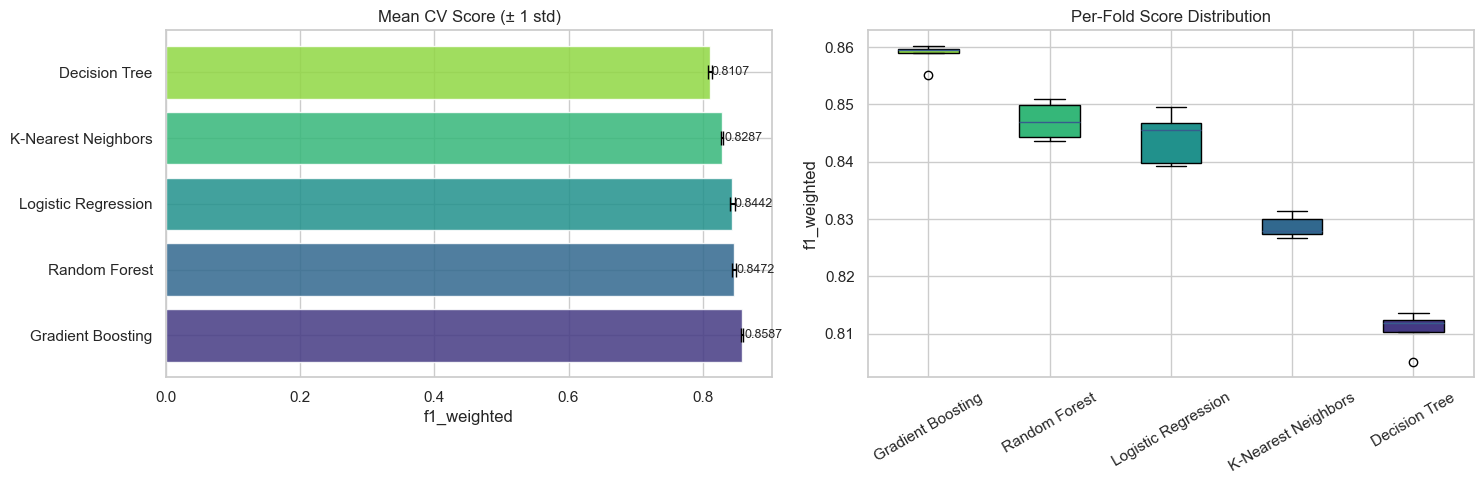

In [13]:
sorted_names = sorted(cv_results, key=lambda k: cv_results[k].mean(), reverse=True)
means  = [cv_results[n].mean() for n in sorted_names]
stds   = [cv_results[n].std()  for n in sorted_names]
colors = sns.color_palette('viridis', len(sorted_names))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
bars = axes[0].barh(sorted_names, means, xerr=stds,
                    capsize=5, color=colors, alpha=0.85)
axes[0].set_xlabel(CONFIG['scoring'])
axes[0].set_title('Mean CV Score (± 1 std)')
for bar, mean in zip(bars, means):
    axes[0].text(mean + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{mean:.4f}', va='center', fontsize=9)

# Box plot of per-fold scores
plot_data = [cv_results[n] for n in sorted_names]
bp = axes[1].boxplot(plot_data, vert=True, patch_artist=True, labels=sorted_names)
for patch, color in zip(bp['boxes'], reversed(colors)):
    patch.set_facecolor(color)
axes[1].set_ylabel(CONFIG['scoring'])
axes[1].set_title('Per-Fold Score Distribution')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 10 · Hyperparameter Tuning (Best Model)
> GridSearchCV over the top CV model. Extend `PARAM_GRIDS` for any classifier.

In [14]:
PARAM_GRIDS = {
    'Logistic Regression' : {
        'classifier__C'      : [0.01, 0.1, 1, 10, 100],
        'classifier__solver' : ['lbfgs', 'liblinear'],
        'classifier__penalty': ['l2'],
    },
    'Decision Tree' : {
        'classifier__max_depth'       : [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__criterion'        : ['gini', 'entropy'],
    },
    'Random Forest' : {
        'classifier__n_estimators' : [100, 200],
        'classifier__max_depth'    : [None, 5, 10],
        'classifier__min_samples_split': [2, 5],
    },
    'Gradient Boosting' : {
        'classifier__n_estimators'  : [100, 200],
        'classifier__learning_rate' : [0.05, 0.1, 0.2],
        'classifier__max_depth'     : [3, 5],
    },
    'K-Nearest Neighbors' : {
        'classifier__n_neighbors': [3, 5, 7, 11, 15],
        'classifier__weights'    : ['uniform', 'distance'],
        'classifier__metric'     : ['euclidean', 'manhattan'],
    },
    'SVM (RBF)' : {
        'classifier__C'     : [0.1, 1, 10],
        'classifier__gamma' : ['scale', 'auto'],
        'classifier__kernel': ['rbf', 'linear'],
    },
}

best_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'Best model from CV  : {best_name}')
print(f'Mean {CONFIG["scoring"]:15s}: {cv_results[best_name].mean():.4f}')

if best_name in PARAM_GRIDS:
    print(f'\nRunning GridSearchCV for {best_name} ...')
    grid = GridSearchCV(
        pipelines[best_name],
        PARAM_GRIDS[best_name],
        cv      = cv,
        scoring = CONFIG['scoring'],
        n_jobs  = -1,
        verbose = 1
    )
    grid.fit(X_train, y_train)
    best_pipeline = grid.best_estimator_
    print(f'\nBest params  : {grid.best_params_}')
    print(f'Best CV score: {grid.best_score_:.4f}')
else:
    print('No param grid defined — fitting default pipeline.')
    best_pipeline = pipelines[best_name]
    best_pipeline.fit(X_train, y_train)

Best model from CV  : Gradient Boosting
Mean f1_weighted    : 0.8587

Running GridSearchCV for Gradient Boosting ...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params  : {'classifier__learning_rate': 0.2, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}
Best CV score: 0.8672


## 11 · Final Test-Set Evaluation

  Final Evaluation → Gradient Boosting
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      4939
        >50K       0.78      0.68      0.72      1568

    accuracy                           0.88      6507
   macro avg       0.84      0.81      0.82      6507
weighted avg       0.87      0.88      0.87      6507



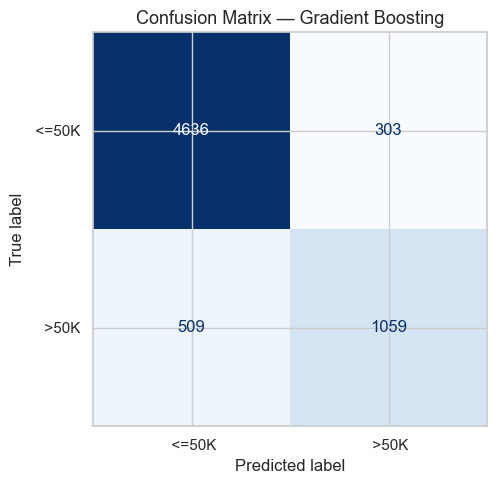

In [15]:
y_pred = best_pipeline.predict(X_test)

print('=' * 55)
print(f'  Final Evaluation → {best_name}')
print('=' * 55)
print(classification_report(y_test, y_pred))

# Confusion matrix
cm  = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix   = cm,
    display_labels     = best_pipeline.classes_
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

## 12 · ROC Curve

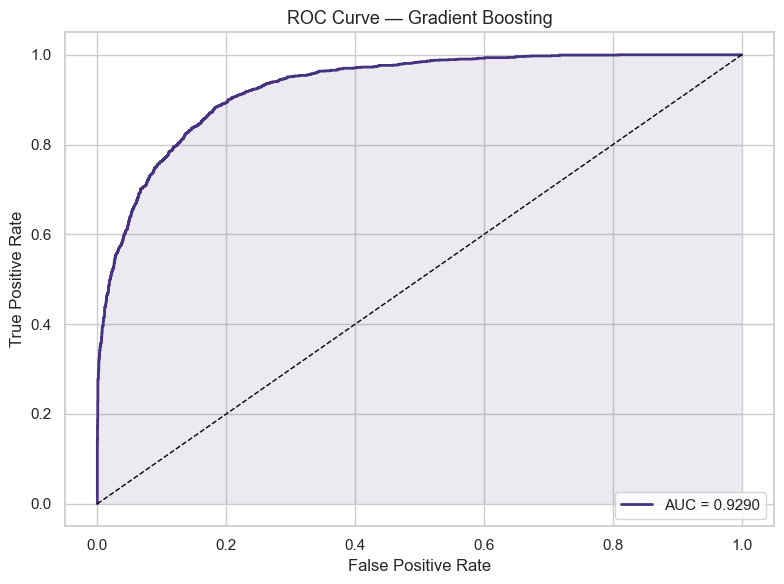

In [16]:
classes    = best_pipeline.classes_
y_prob     = best_pipeline.predict_proba(X_test)

fig, ax = plt.subplots(figsize=(8, 6))

if len(classes) == 2:
    # ── Binary ──────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1], pos_label=classes[1])
    auc = roc_auc_score(y_test, y_prob[:, 1])
    ax.plot(fpr, tpr, lw=2, label=f'AUC = {auc:.4f}')
    ax.fill_between(fpr, tpr, alpha=0.1)
else:
    # ── Multi-class One-vs-Rest ──────────────────────
    y_bin = label_binarize(y_test, classes=classes)
    palette = sns.color_palette('tab10', len(classes))
    for i, (cls, color) in enumerate(zip(classes, palette)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        auc = roc_auc_score(y_bin[:, i], y_prob[:, i])
        ax.plot(fpr, tpr, lw=2, color=color, label=f'Class {cls}  AUC={auc:.2f}')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curve — {best_name}', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 13 · Feature Importances

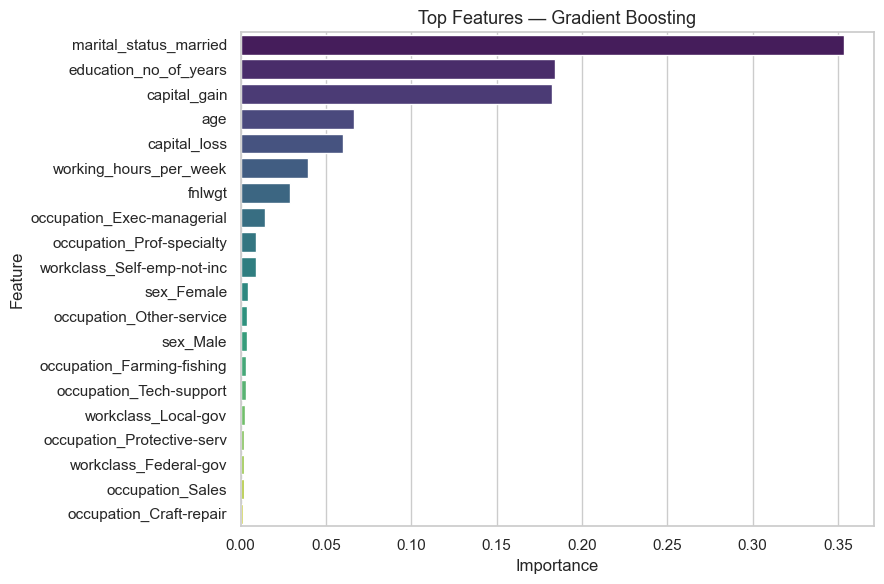

,Feature,Importance
0,marital_status_married,0.353423
1,education_no_of_years,0.184327
2,capital_gain,0.182183
3,age,0.066492
4,capital_loss,0.059747
5,working_hours_per_week,0.039397
6,fnlwgt,0.029012
7,occupation_Exec-managerial,0.014464
8,occupation_Prof-specialty,0.008993
9,workclass_Self-emp-not-inc,0.008992


In [17]:
# Recover feature names post-preprocessing
def get_feature_names(pipeline, num_cols, cat_cols):
    prep = pipeline.named_steps['preprocessor']
    names = list(num_cols)
    for name, trans, cols in prep.transformers_:
        if name == 'cat' and hasattr(trans.named_steps.get('encoder', {}), 'get_feature_names_out'):
            names += trans.named_steps['encoder'].get_feature_names_out(cols).tolist()
    return names

feature_names = get_feature_names(best_pipeline, num_cols, cat_cols)
clf = best_pipeline.named_steps['classifier']

if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    fi_label    = 'Importance'
elif hasattr(clf, 'coef_'):
    raw = clf.coef_
    importances = np.abs(raw[0] if raw.ndim > 1 and raw.shape[0] == 1 else raw.mean(axis=0))
    fi_label    = '|Coefficient|'
else:
    print(f'{best_name} does not expose feature weights directly.')
    importances = None

if importances is not None:
    n = min(len(importances), len(feature_names))
    fi_df = (
        pd.DataFrame({'Feature': feature_names[:n], fi_label: importances[:n]})
        .sort_values(fi_label, ascending=False)
        .head(20)
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(data=fi_df, x=fi_label, y='Feature',
                palette='viridis', ax=ax)
    ax.set_title(f'Top Features — {best_name}', fontsize=13)
    plt.tight_layout()
    plt.show()
    display(fi_df.reset_index(drop=True))

## 14 · Save & Reload Model

In [20]:
import os

if CONFIG['save_model']:
    model_filename = os.path.join(
        CONFIG['model_dir'],
        f"best_model_{best_name.replace(' ', '_').lower()}.pkl"
    )
    os.makedirs(os.path.dirname(model_filename), exist_ok=True)
    joblib.dump(best_pipeline, model_filename)
    print(f'Pipeline saved → {model_filename}')

# ── Reload & predict (template) ───────────────────
# loaded = joblib.load(model_filename)
# new_preds = loaded.predict(X_new)

Pipeline saved → Python for Data Analysis\Assignment 1\saved_models\best_model_gradient_boosting.pkl


## 15 · Predict on New Data
> Pass a raw DataFrame — the pipeline handles all preprocessing automatically.

In [21]:
def predict_new(pipeline, raw_df):
    """
    Parameters
    ----------
    pipeline : fitted sklearn Pipeline
    raw_df   : pd.DataFrame with the same columns as training X

    Returns
    -------
    preds     : array of class labels
    proba_df  : DataFrame of class probabilities
    """
    preds    = pipeline.predict(raw_df)
    probas   = pipeline.predict_proba(raw_df)
    proba_df = pd.DataFrame(probas, columns=pipeline.classes_)
    return preds, proba_df

# Example — uncomment and replace with your new data
# new_data = pd.DataFrame([{ ... }])          # one or more rows
# preds, proba_df = predict_new(best_pipeline, new_data)
# print('Predictions :', preds)
# display(proba_df)

print('predict_new() helper ready ✓')

predict_new() helper ready ✓
